# 01 — Persiapan Dataset dan Exploratory Data Analysis (EDA)

by: Muhammad Bondan Vitto Ramadhan

NIM : 2702831190

**Proyek:** Klasifikasi 37 ras kucing dan anjing pada Oxford-IIIT Pet Dataset  
**Desain eksperimen:** CNN versus Vision Transformer (ViT)  
**Tujuan notebook ini:**

1. Memeriksa environment Google Colab.
2. Mengunduh dan mengekstrak dataset secara aman dan *idempotent*.
3. Memvalidasi label, file gambar, dan kualitas data.
4. Melakukan EDA untuk distribusi kelas, spesies, dan ukuran gambar.
5. Membuat split **train/validation/test** tanpa kebocoran data.
6. Menyimpan metadata dan visualisasi untuk notebook 02 dan 03.

Sumber resmi dataset: <https://www.robots.ox.ac.uk/~vgg/data/pets/>

## 1. Preparation

In [1]:
import json
import os
import random
import re
import shutil
import sys
import tarfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import torch
from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 100)

print("Python version :", sys.version.split()[0])
print("PyTorch version:", torch.__version__)
print("Pandas version :", pd.__version__)
print("CUDA available :", torch.cuda.is_available())

Python version : 3.13.15
PyTorch version: 2.11.0+cpu
Pandas version : 2.2.3
CUDA available : False


In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cpu
CUDA available: False


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [6]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision")
#/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision
RAW_DIR = PROJECT_DIR / "data" / "raw"
OUTPUT_DIR = PROJECT_DIR / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
HISTORY_DIR = OUTPUT_DIR / "histories"
FIGURE_DIR = OUTPUT_DIR / "figures"
METRIC_DIR = OUTPUT_DIR / "metrics"

for folder in [
    RAW_DIR,
    CHECKPOINT_DIR,
    HISTORY_DIR,
    FIGURE_DIR,
    METRIC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print(PROJECT_DIR)

/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision


## 2. Download dan verifikasi arsip

Cell berikut **tidak mengunduh ulang** file yang sudah ada dan ukurannya masuk
akal. Jika koneksi terputus, file sementara menggunakan ekstensi `.part`, sehingga
arsip yang sudah valid tidak rusak.

In [9]:
!wget -c \
  https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz \
  -O "/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/raw/images.tar.gz"

!wget -c \
  https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz \
  -O "/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/raw/annotations.tar.gz"

--2026-09-19 06:03:06--  https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-09-19 06:03:06--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Reusing existing connection to thor.robots.ox.ac.uk:443.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/raw/images.tar.gz’

/content/drive/MyDr 100%[===================>] 755.23M  12.5MB/s    in 32s     

2026-09-19 06:03:38 (23.8 MB/s) - ‘/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/raw/images.tar.gz’ saved [791918971/791918971]

--2026-09-19 

In [10]:
images_archive = RAW_DIR / "images.tar.gz"
annotations_archive = RAW_DIR / "annotations.tar.gz"

print("Images archive:", images_archive.exists())
print("Annotations archive:", annotations_archive.exists())

Images archive: True
Annotations archive: True


In [15]:
DATASET_URLS = {
    "images": "https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz",
    "annotations": "https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz",
}

images_archive = RAW_DIR / "images.tar.gz"
annotations_archive = RAW_DIR / "annotations.tar.gz"

# Batas bawah untuk mendeteksi unduhan yang gagal/terpotong.
MIN_ARCHIVE_BYTES = {
    images_archive: 700 * 1024**2,
    annotations_archive: 15 * 1024**2,
}


def download_if_needed(url: str, destination: Path, min_bytes: int) -> None:
    """Unduh file hanya jika belum ada atau ukurannya terlalu kecil."""
    if destination.exists() and destination.stat().st_size >= min_bytes:
        size_mb = destination.stat().st_size / 1024**2
        print(f"Lewati download: {destination.name} sudah ada ({size_mb:.1f} MB)")
        return

    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = Path(str(destination) + ".part")

    if temporary_path.exists():
        temporary_path.unlink()

    print(f"Mengunduh {destination.name} ...")
    with requests.get(url, stream=True, timeout=(30, 300)) as response:
        response.raise_for_status()
        total_bytes = int(response.headers.get("content-length", 0))
        with temporary_path.open("wb") as file_obj, tqdm(
            total=total_bytes,
            unit="B",
            unit_scale=True,
            desc=destination.name,
        ) as progress:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    file_obj.write(chunk)
                    progress.update(len(chunk))

    if temporary_path.stat().st_size < min_bytes:
        raise RuntimeError(
            f"Ukuran {temporary_path.name} terlalu kecil. "
            "Hapus file .part dan ulangi download."
        )

    temporary_path.replace(destination)
    print(f"Selesai: {destination}")


download_if_needed(
    DATASET_URLS["images"],
    images_archive,
    MIN_ARCHIVE_BYTES[images_archive],
)
download_if_needed(
    DATASET_URLS["annotations"],
    annotations_archive,
    MIN_ARCHIVE_BYTES[annotations_archive],
)

Lewati download: images.tar.gz sudah ada (755.2 MB)
Lewati download: annotations.tar.gz sudah ada (18.3 MB)


In [16]:
archive_status = pd.DataFrame(
    [
        {
            "archive": path.name,
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024**2, 2)
            if path.exists()
            else np.nan,
            "size_check": path.exists()
            and path.stat().st_size >= MIN_ARCHIVE_BYTES[path],
        }
        for path in [images_archive, annotations_archive]
    ]
)

display(archive_status)
assert archive_status["size_check"].all(), "Ada arsip yang belum lengkap."

,archive,exists,size_mb,size_check
0,images.tar.gz,True,755.23,True
1,annotations.tar.gz,True,18.28,True


## 3. Ekstraksi dataset ke penyimpanan lokal Colab

Ekstraksi menggunakan filter aman dan pemeriksaan *path traversal*. Cell ini
juga bersifat *idempotent*: jika dataset sudah lengkap di runtime saat ini,
ekstraksi akan dilewati.

In [8]:
LOCAL_ROOT = Path("/content/oxford_iiit_pet")
LOCAL_ARCHIVE_DIR = Path("/content/oxford_iiit_pet_archives")
LOCAL_IMAGES_DIR = LOCAL_ROOT / "images"
LOCAL_ANNOTATIONS_DIR = LOCAL_ROOT / "annotations"

LOCAL_ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

In [17]:



def extraction_is_complete() -> bool:
    required_files = [
        LOCAL_ANNOTATIONS_DIR / "trainval.txt",
        LOCAL_ANNOTATIONS_DIR / "test.txt",
        LOCAL_ANNOTATIONS_DIR / "list.txt",
    ]
    image_count = (
        len(list(LOCAL_IMAGES_DIR.glob("*.jpg")))
        if LOCAL_IMAGES_DIR.exists()
        else 0
    )
    return image_count >= 7_349 and all(path.exists() for path in required_files)


def safe_extract_tar(archive_path: Path, destination: Path) -> None:
    """Ekstrak TAR sambil menolak path traversal dan symbolic link."""
    destination.mkdir(parents=True, exist_ok=True)
    destination_resolved = destination.resolve()

    with tarfile.open(archive_path, mode="r:gz") as archive:
        members = archive.getmembers()

        for member in members:
            target = (destination / member.name).resolve()
            if target != destination_resolved and destination_resolved not in target.parents:
                raise RuntimeError(f"Path tidak aman di dalam arsip: {member.name}")
            if member.issym() or member.islnk():
                raise RuntimeError(f"Link tidak diizinkan di dalam arsip: {member.name}")

        try:
            archive.extractall(destination, members=members, filter="data")
        except TypeError:
            # Fallback untuk Python lama; pemeriksaan path sudah dilakukan di atas.
            archive.extractall(destination, members=members)


if extraction_is_complete():
    print("Dataset lokal sudah lengkap; ekstraksi dilewati.")
else:
    local_images_archive = LOCAL_ARCHIVE_DIR / images_archive.name
    local_annotations_archive = LOCAL_ARCHIVE_DIR / annotations_archive.name

    print("Menyalin arsip dari Drive ke penyimpanan lokal Colab ...")
    shutil.copy2(images_archive, local_images_archive)
    shutil.copy2(annotations_archive, local_annotations_archive)

    print("Mengekstrak images.tar.gz ...")
    safe_extract_tar(local_images_archive, LOCAL_ROOT)
    print("Mengekstrak annotations.tar.gz ...")
    safe_extract_tar(local_annotations_archive, LOCAL_ROOT)

    print("Ekstraksi selesai.")

Menyalin arsip dari Drive ke penyimpanan lokal Colab ...
Mengekstrak images.tar.gz ...
Mengekstrak annotations.tar.gz ...
Ekstraksi selesai.


In [12]:
all_image_paths = sorted(LOCAL_IMAGES_DIR.glob("*.jpg"))
required_annotation_paths = {
    "trainval": LOCAL_ANNOTATIONS_DIR / "trainval.txt",
    "test": LOCAL_ANNOTATIONS_DIR / "test.txt",
    "list": LOCAL_ANNOTATIONS_DIR / "list.txt",
}

print("Jumlah file JPG     :", f"{len(all_image_paths):,}")
print("Folder annotation   :", LOCAL_ANNOTATIONS_DIR.exists())
for name, path in required_annotation_paths.items():
    print(f"{name:>8}.txt tersedia:", path.exists())

assert len(all_image_paths) >= 7_349, "Jumlah gambar lebih sedikit dari label resmi."
assert all(path.exists() for path in required_annotation_paths.values())

Jumlah file JPG     : 7,390
Folder annotation   : True
trainval.txt tersedia: True
    test.txt tersedia: True
    list.txt tersedia: True


In [6]:
# ============================================================
# Menetapkan struktur penyimpanan permanen di Google Drive
# ============================================================

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
DRIVE_DATASET_DIR = DATA_DIR / "oxford_iiit_pet"
METADATA_DIR = DATA_DIR / "metadata"

OUTPUT_DIR = PROJECT_DIR / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
HISTORY_DIR = OUTPUT_DIR / "histories"
FIGURE_DIR = OUTPUT_DIR / "figures"
METRIC_DIR = OUTPUT_DIR / "metrics"

for folder in [
    RAW_DIR,
    DRIVE_DATASET_DIR,
    METADATA_DIR,
    CHECKPOINT_DIR,
    HISTORY_DIR,
    FIGURE_DIR,
    METRIC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Raw archives :", RAW_DIR)
print("Dataset      :", DRIVE_DATASET_DIR)
print("Metadata     :", METADATA_DIR)
print("Figures      :", FIGURE_DIR)

Raw archives : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/raw
Dataset      : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/oxford_iiit_pet
Metadata     : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/metadata
Figures      : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures


In [9]:
# ============================================================
# Menyalin dataset hasil ekstraksi ke Google Drive
# ============================================================

def drive_dataset_is_complete():
    drive_images_dir = DRIVE_DATASET_DIR / "images"
    drive_annotations_dir = DRIVE_DATASET_DIR / "annotations"

    required_files = [
        drive_annotations_dir / "trainval.txt",
        drive_annotations_dir / "test.txt",
        drive_annotations_dir / "list.txt",
    ]

    image_count = (
        len(list(drive_images_dir.glob("*.jpg")))
        if drive_images_dir.exists()
        else 0
    )

    return image_count >= 7_349 and all(
        path.exists() for path in required_files
    )


if drive_dataset_is_complete():
    print("Dataset lengkap sudah tersedia di Google Drive.")
else:
    assert LOCAL_ROOT.exists(), (
        "Dataset lokal tidak ditemukan. "
        "Jalankan kembali bagian ekstraksi terlebih dahulu."
    )

    print("Menyalin dataset ke Google Drive...")
    print("Proses ini dapat memerlukan waktu karena jumlah file cukup banyak.")

    shutil.copytree(
        LOCAL_ROOT,
        DRIVE_DATASET_DIR,
        dirs_exist_ok=True,
    )

    print("Penyalinan dataset selesai.")

print(
    "Jumlah gambar di Drive:",
    len(list((DRIVE_DATASET_DIR / "images").glob("*.jpg")))
)

assert drive_dataset_is_complete(), (
    "Dataset di Google Drive belum lengkap."
)

Menyalin dataset ke Google Drive...
Proses ini dapat memerlukan waktu karena jumlah file cukup banyak.
Penyalinan dataset selesai.
Jumlah gambar di Drive: 7390


## 4. Membaca label resmi

Format setiap baris pada `trainval.txt` dan `test.txt` adalah:

```text
image_name class_id species_id breed_id
```

- `class_id`: 1–37, yaitu ras hewan.
- `species_id`: 1 untuk kucing dan 2 untuk anjing.
- `breed_id`: indeks ras di dalam kelompok spesies.

Model PyTorch akan menggunakan `class_idx` 0–36, sementara `class_id` asli tetap
disimpan agar metadata dapat ditelusuri kembali ke anotasi resmi.

In [13]:
SPECIES_MAP = {1: "Cat", 2: "Dog"}


def class_name_from_image_name(image_name: str) -> str:
    """Hapus nomor gambar terakhir, misalnya Abyssinian_12 -> Abyssinian."""
    return re.sub(r"_\d+$", "", image_name)


def parse_split_file(annotation_path: Path, official_split: str) -> pd.DataFrame:
    records = []

    with annotation_path.open("r", encoding="utf-8") as file_obj:
        for line_number, line in enumerate(file_obj, start=1):
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            parts = line.split()
            if len(parts) != 4:
                raise ValueError(
                    f"Format tidak valid pada {annotation_path.name} "
                    f"baris {line_number}: {line}"
                )

            image_name, class_id, species_id, breed_id = parts
            class_id = int(class_id)
            species_id = int(species_id)
            breed_id = int(breed_id)

            records.append(
                {
                    "image_name": image_name,
                    "file_name": f"{image_name}.jpg",
                    "image_path": str(LOCAL_IMAGES_DIR / f"{image_name}.jpg"),
                    "class_id": class_id,
                    "class_idx": class_id - 1,
                    "class_name": class_name_from_image_name(image_name),
                    "species_id": species_id,
                    "species": SPECIES_MAP.get(species_id, "Unknown"),
                    "breed_id": breed_id,
                    "official_split": official_split,
                }
            )

    return pd.DataFrame(records)


trainval_df = parse_split_file(
    required_annotation_paths["trainval"], official_split="trainval"
)
test_df = parse_split_file(required_annotation_paths["test"], official_split="test")
dataset_df = pd.concat([trainval_df, test_df], ignore_index=True)

print("Trainval resmi:", f"{len(trainval_df):,}")
print("Test resmi    :", f"{len(test_df):,}")
print("Total berlabel:", f"{len(dataset_df):,}")
display(dataset_df.head())

Trainval resmi: 3,680
Test resmi    : 3,669
Total berlabel: 7,349


,image_name,file_name,image_path,class_id,class_idx,class_name,species_id,species,breed_id,official_split
0,Abyssinian_100,Abyssinian_100.jpg,/content/oxford_iiit_pet/images/Abyssinian_100.jpg,1,0,Abyssinian,1,Cat,1,trainval
1,Abyssinian_101,Abyssinian_101.jpg,/content/oxford_iiit_pet/images/Abyssinian_101.jpg,1,0,Abyssinian,1,Cat,1,trainval
2,Abyssinian_102,Abyssinian_102.jpg,/content/oxford_iiit_pet/images/Abyssinian_102.jpg,1,0,Abyssinian,1,Cat,1,trainval
3,Abyssinian_103,Abyssinian_103.jpg,/content/oxford_iiit_pet/images/Abyssinian_103.jpg,1,0,Abyssinian,1,Cat,1,trainval
4,Abyssinian_104,Abyssinian_104.jpg,/content/oxford_iiit_pet/images/Abyssinian_104.jpg,1,0,Abyssinian,1,Cat,1,trainval


In [14]:
annotated_files = set(dataset_df["file_name"])
available_files = {path.name for path in all_image_paths}

missing_files = sorted(annotated_files - available_files)
unused_files = sorted(available_files - annotated_files)
duplicate_rows = dataset_df[dataset_df.duplicated("image_name", keep=False)]

validation_summary = pd.DataFrame(
    {
        "check": [
            "Gambar berlabel",
            "File JPG tersedia",
            "File label yang hilang",
            "File JPG tidak dipakai split resmi",
            "Nama gambar duplikat",
            "Jumlah kelas",
            "Jumlah spesies",
        ],
        "value": [
            len(dataset_df),
            len(available_files),
            len(missing_files),
            len(unused_files),
            len(duplicate_rows),
            dataset_df["class_idx"].nunique(),
            dataset_df["species_id"].nunique(),
        ],
    }
)

display(validation_summary)

assert not missing_files, f"Ada gambar berlabel yang hilang: {missing_files[:5]}"
assert duplicate_rows.empty, "Nama gambar muncul lebih dari satu kali."
assert dataset_df["class_idx"].nunique() == 37, "Jumlah kelas bukan 37."
assert set(dataset_df["species_id"]) == {1, 2}, "Label spesies tidak valid."
assert dataset_df["class_idx"].between(0, 36).all()

if unused_files:
    print(f"Contoh file yang tidak digunakan ({len(unused_files)} file):")
    print(unused_files[:10])

,check,value
0,Gambar berlabel,7349
1,File JPG tersedia,7390
2,File label yang hilang,0
3,File JPG tidak dipakai split resmi,41
4,Nama gambar duplikat,0
5,Jumlah kelas,37
6,Jumlah spesies,2


Contoh file yang tidak digunakan (41 file):
['Abyssinian_34.jpg', 'Abyssinian_82.jpg', 'Bombay_11.jpg', 'Bombay_189.jpg', 'Bombay_190.jpg', 'Bombay_192.jpg', 'Bombay_203.jpg', 'Bombay_206.jpg', 'Bombay_209.jpg', 'Bombay_210.jpg']


## 5. Pemeriksaan integritas dan karakteristik gambar

Pemeriksaan penuh membaca header seluruh gambar berlabel dan mencatat dimensi,
mode warna, rasio aspek, serta ukuran file. Proses ini biasanya memerlukan waktu
kurang dari beberapa menit karena data sudah berada di `/content`.

In [16]:
RUN_FULL_IMAGE_CHECK = True


def inspect_image(image_path: Path) -> dict:
    with Image.open(image_path) as image:
        image = ImageOps.exif_transpose(image)
        width, height = image.size
        mode = image.mode
        image.verify()

    return {
        "file_name": image_path.name,
        "width": width,
        "height": height,
        "aspect_ratio": width / height,
        "file_size_kb": image_path.stat().st_size / 1024,
        "image_mode": mode,
        "is_valid": True,
        "error": "",
    }


rows_to_check = dataset_df
if not RUN_FULL_IMAGE_CHECK:
    rows_to_check = dataset_df.sample(n=min(500, len(dataset_df)), random_state=SEED)

image_metadata = []
for row in tqdm(
    rows_to_check.itertuples(index=False),
    total=len(rows_to_check),
    desc="Memeriksa gambar",
):
    image_path = Path(row.image_path)
    try:
        image_metadata.append(inspect_image(image_path))
    except Exception as exc:
        image_metadata.append(
            {
                "file_name": row.file_name,
                "width": np.nan,
                "height": np.nan,
                "aspect_ratio": np.nan,
                "file_size_kb": np.nan,
                "image_mode": "Unknown",
                "is_valid": False,
                "error": repr(exc),
            }
        )

image_metadata_df = pd.DataFrame(image_metadata)
broken_images = image_metadata_df.loc[~image_metadata_df["is_valid"]]

print("Gambar diperiksa:", f"{len(image_metadata_df):,}")
print("Gambar bermasalah:", f"{len(broken_images):,}")

if not broken_images.empty:
    display(broken_images)
    raise RuntimeError(
        "Ditemukan gambar rusak. Periksa tabel di atas sebelum melanjutkan."
    )

if RUN_FULL_IMAGE_CHECK:
    dataset_df = dataset_df.merge(
        image_metadata_df.drop(columns=["is_valid", "error"]),
        on="file_name",
        how="left",
        validate="one_to_one",
    )

Memeriksa gambar:   0%|          | 0/7349 [00:00<?, ?it/s]

Gambar diperiksa: 7,349
Gambar bermasalah: 0


In [17]:
if RUN_FULL_IMAGE_CHECK:
    display(
        dataset_df[
            ["width", "height", "aspect_ratio", "file_size_kb"]
        ].describe().round(2)
    )
    print("Mode warna:")
    display(dataset_df["image_mode"].value_counts().rename_axis("mode").to_frame("count"))

,width,height,aspect_ratio,file_size_kb
count,7349.00,7349.00,7349.00,7349.00
mean,437.24,391.39,1.17,105.09
std,115.78,109.39,0.33,57.27
min,114.00,103.00,0.42,3.34
25%,337.00,333.00,0.75,76.30
50%,500.00,375.00,1.33,105.29
75%,500.00,500.00,1.49,135.92
max,3264.00,2606.00,2.56,1098.78


Mode warna:


,count
mode,
RGB,7346
RGBA,3


## 6. Exploratory Data Analysis

### Ringkasan dataset

In [18]:
dataset_summary_table = pd.DataFrame(
    [
        ("Gambar berlabel", len(dataset_df)),
        ("Trainval resmi", (dataset_df["official_split"] == "trainval").sum()),
        ("Test resmi", (dataset_df["official_split"] == "test").sum()),
        ("Jumlah kelas ras", dataset_df["class_idx"].nunique()),
        ("Jumlah gambar kucing", (dataset_df["species"] == "Cat").sum()),
        ("Jumlah gambar anjing", (dataset_df["species"] == "Dog").sum()),
        ("File JPG tidak digunakan", len(unused_files)),
        ("Gambar rusak", len(broken_images)),
    ],
    columns=["Statistik", "Nilai"],
)

display(dataset_summary_table)

,Statistik,Nilai
0,Gambar berlabel,7349
1,Trainval resmi,3680
2,Test resmi,3669
3,Jumlah kelas ras,37
4,Jumlah gambar kucing,2371
5,Jumlah gambar anjing,4978
6,File JPG tidak digunakan,41
7,Gambar rusak,0


official_split,test,trainval,total
class_name,,,
Bombay,88,96,184
staffordshire_bull_terrier,89,100,189
Egyptian_Mau,97,93,190
newfoundland,100,96,196
english_cocker_spaniel,100,96,196
Abyssinian,98,100,198
boxer,99,100,199
keeshond,99,100,199
scottish_terrier,99,100,199


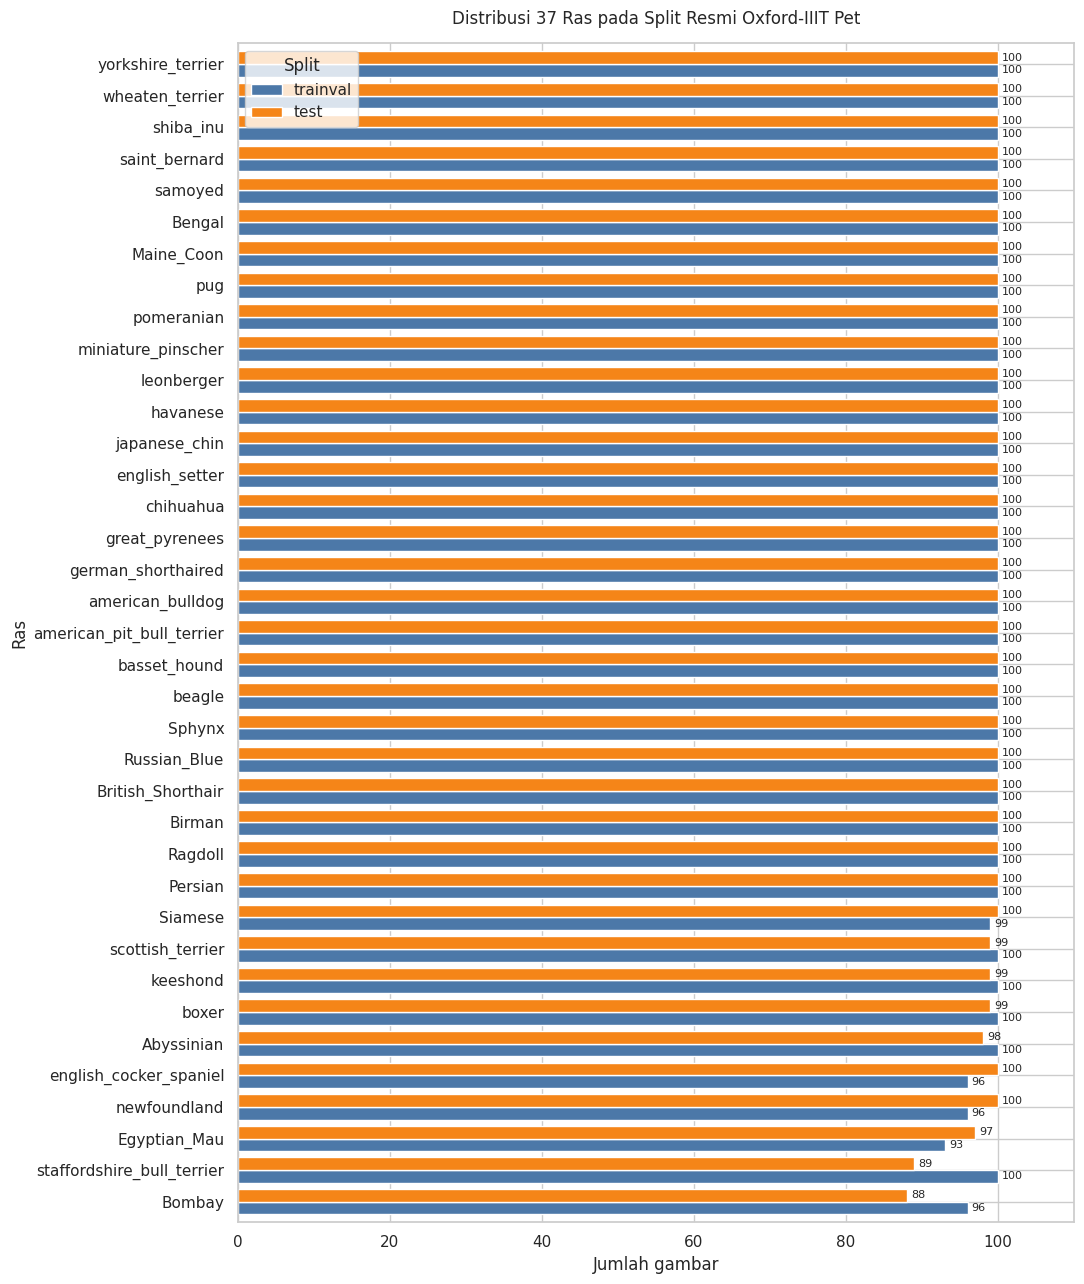

Tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures/01_class_distribution_official_split.png


In [19]:
# 1. Create and display the table
class_distribution = (
    dataset_df.groupby(["class_name", "official_split"])
    .size()
    .unstack(fill_value=0)
)
class_distribution["total"] = class_distribution.sum(axis=1)
class_distribution = class_distribution.sort_values("total", ascending=True)

# Display table in Jupyter / Colab
display(class_distribution)

# Alternatively, print to console or save to CSV
# print(class_distribution)
# class_distribution.to_csv("class_distribution.csv")

# 2. Create the horizontal bar chart with bar labels
fig, ax = plt.subplots(figsize=(11, 13))

class_distribution[["trainval", "test"]].plot(
    kind="barh",
    width=0.8,
    color=["#4C78A8", "#F58518"],
    ax=ax,
)

# Add value labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=8)

ax.set_title("Distribusi 37 Ras pada Split Resmi Oxford-IIIT Pet", pad=14)
ax.set_xlabel("Jumlah gambar")
ax.set_ylabel("Ras")
ax.legend(title="Split")

# Adjust right margin so labels aren't cut off
ax.margins(x=0.1)

plt.tight_layout()

# Save and show
class_distribution_path = FIGURE_DIR / "01_class_distribution_official_split.png"
plt.savefig(class_distribution_path, dpi=300, bbox_inches="tight")
plt.show()

print("Tersimpan:", class_distribution_path)

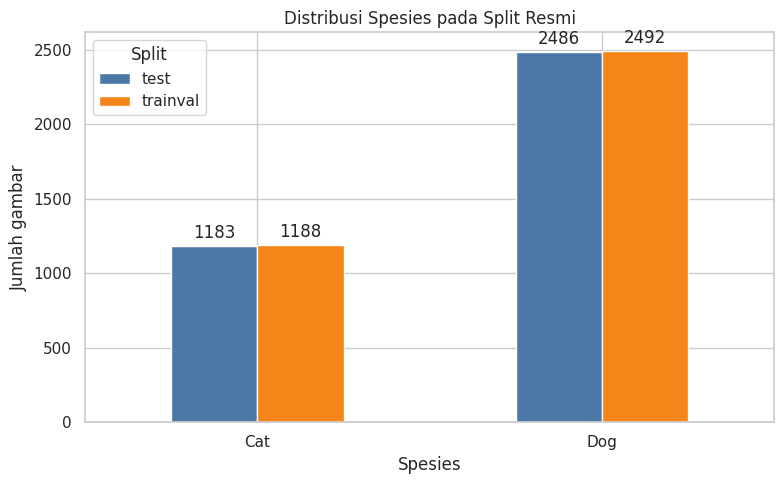

Tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures/01_species_distribution.png


In [20]:
species_distribution = (
    dataset_df.groupby(["species", "official_split"])
    .size()
    .unstack(fill_value=0)
    .reindex(["Cat", "Dog"])
)

ax = species_distribution.plot(
    kind="bar",
    figsize=(8, 5),
    rot=0,
    color=["#4C78A8", "#F58518"],
)
ax.set_title("Distribusi Spesies pada Split Resmi")
ax.set_xlabel("Spesies")
ax.set_ylabel("Jumlah gambar")
ax.legend(title="Split")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
species_distribution_path = FIGURE_DIR / "01_species_distribution.png"
plt.savefig(species_distribution_path, dpi=300, bbox_inches="tight")
plt.show()

print("Tersimpan:", species_distribution_path)

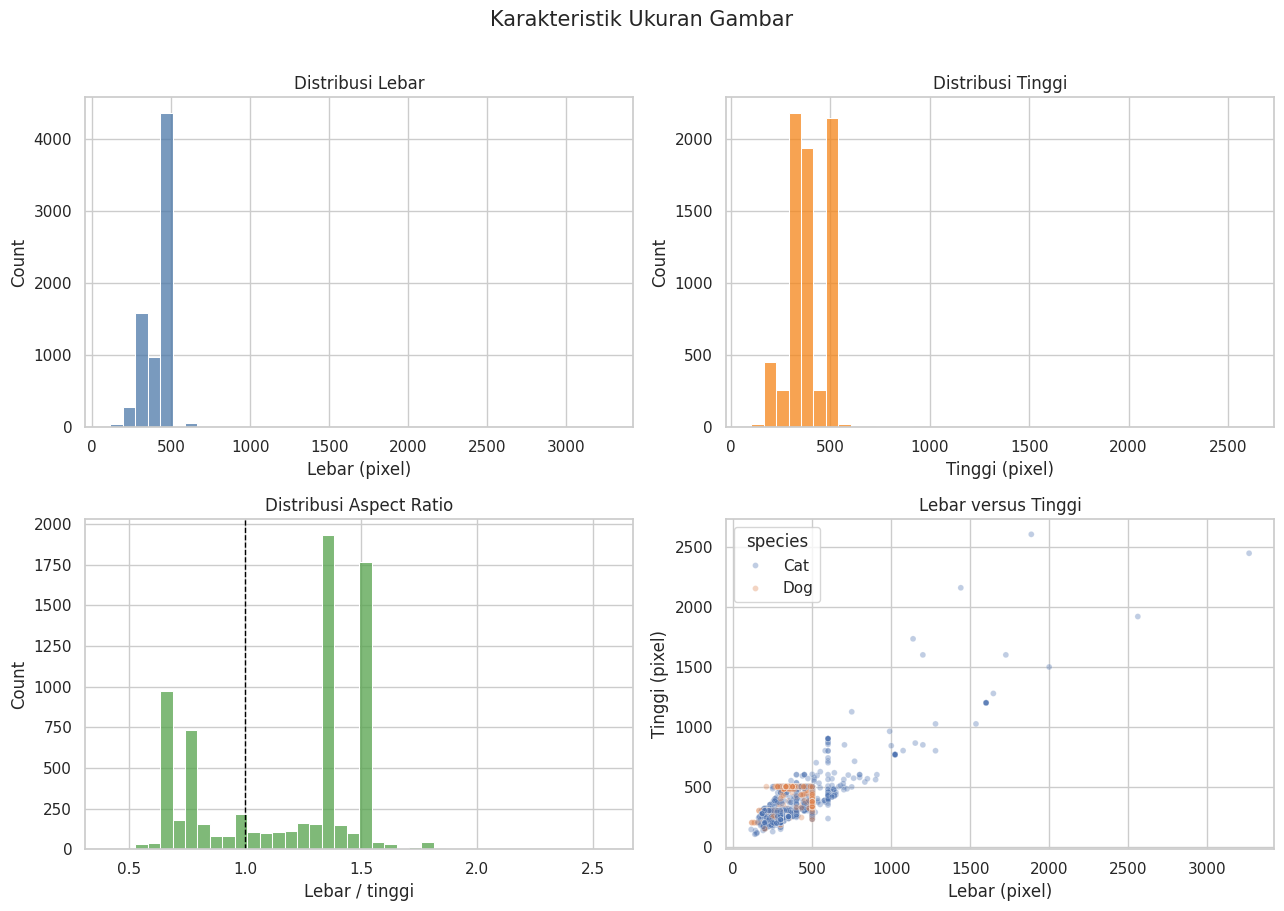

Tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures/01_image_size_distribution.png


In [26]:
if RUN_FULL_IMAGE_CHECK:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    sns.histplot(dataset_df["width"], bins=40, ax=axes[0, 0], color="#4C78A8")
    axes[0, 0].set_title("Distribusi Lebar")
    axes[0, 0].set_xlabel("Lebar (pixel)")

    sns.histplot(dataset_df["height"], bins=40, ax=axes[0, 1], color="#F58518")
    axes[0, 1].set_title("Distribusi Tinggi")
    axes[0, 1].set_xlabel("Tinggi (pixel)")

    sns.histplot(
        dataset_df["aspect_ratio"],
        bins=40,
        ax=axes[1, 0],
        color="#54A24B",
    )
    axes[1, 0].axvline(1.0, color="black", linestyle="--", linewidth=1)
    axes[1, 0].set_title("Distribusi Aspect Ratio")
    axes[1, 0].set_xlabel("Lebar / tinggi")

    sns.scatterplot(
        data=dataset_df,
        x="width",
        y="height",
        hue="species",
        alpha=0.35,
        s=18,
        ax=axes[1, 1],
    )
    axes[1, 1].set_title("Lebar versus Tinggi")
    axes[1, 1].set_xlabel("Lebar (pixel)")
    axes[1, 1].set_ylabel("Tinggi (pixel)")

    fig.suptitle("Karakteristik Ukuran Gambar", fontsize=15, y=1.01)
    plt.tight_layout()

    image_size_path = FIGURE_DIR / "01_image_size_distribution.png"
    plt.savefig(image_size_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Tersimpan:", image_size_path)

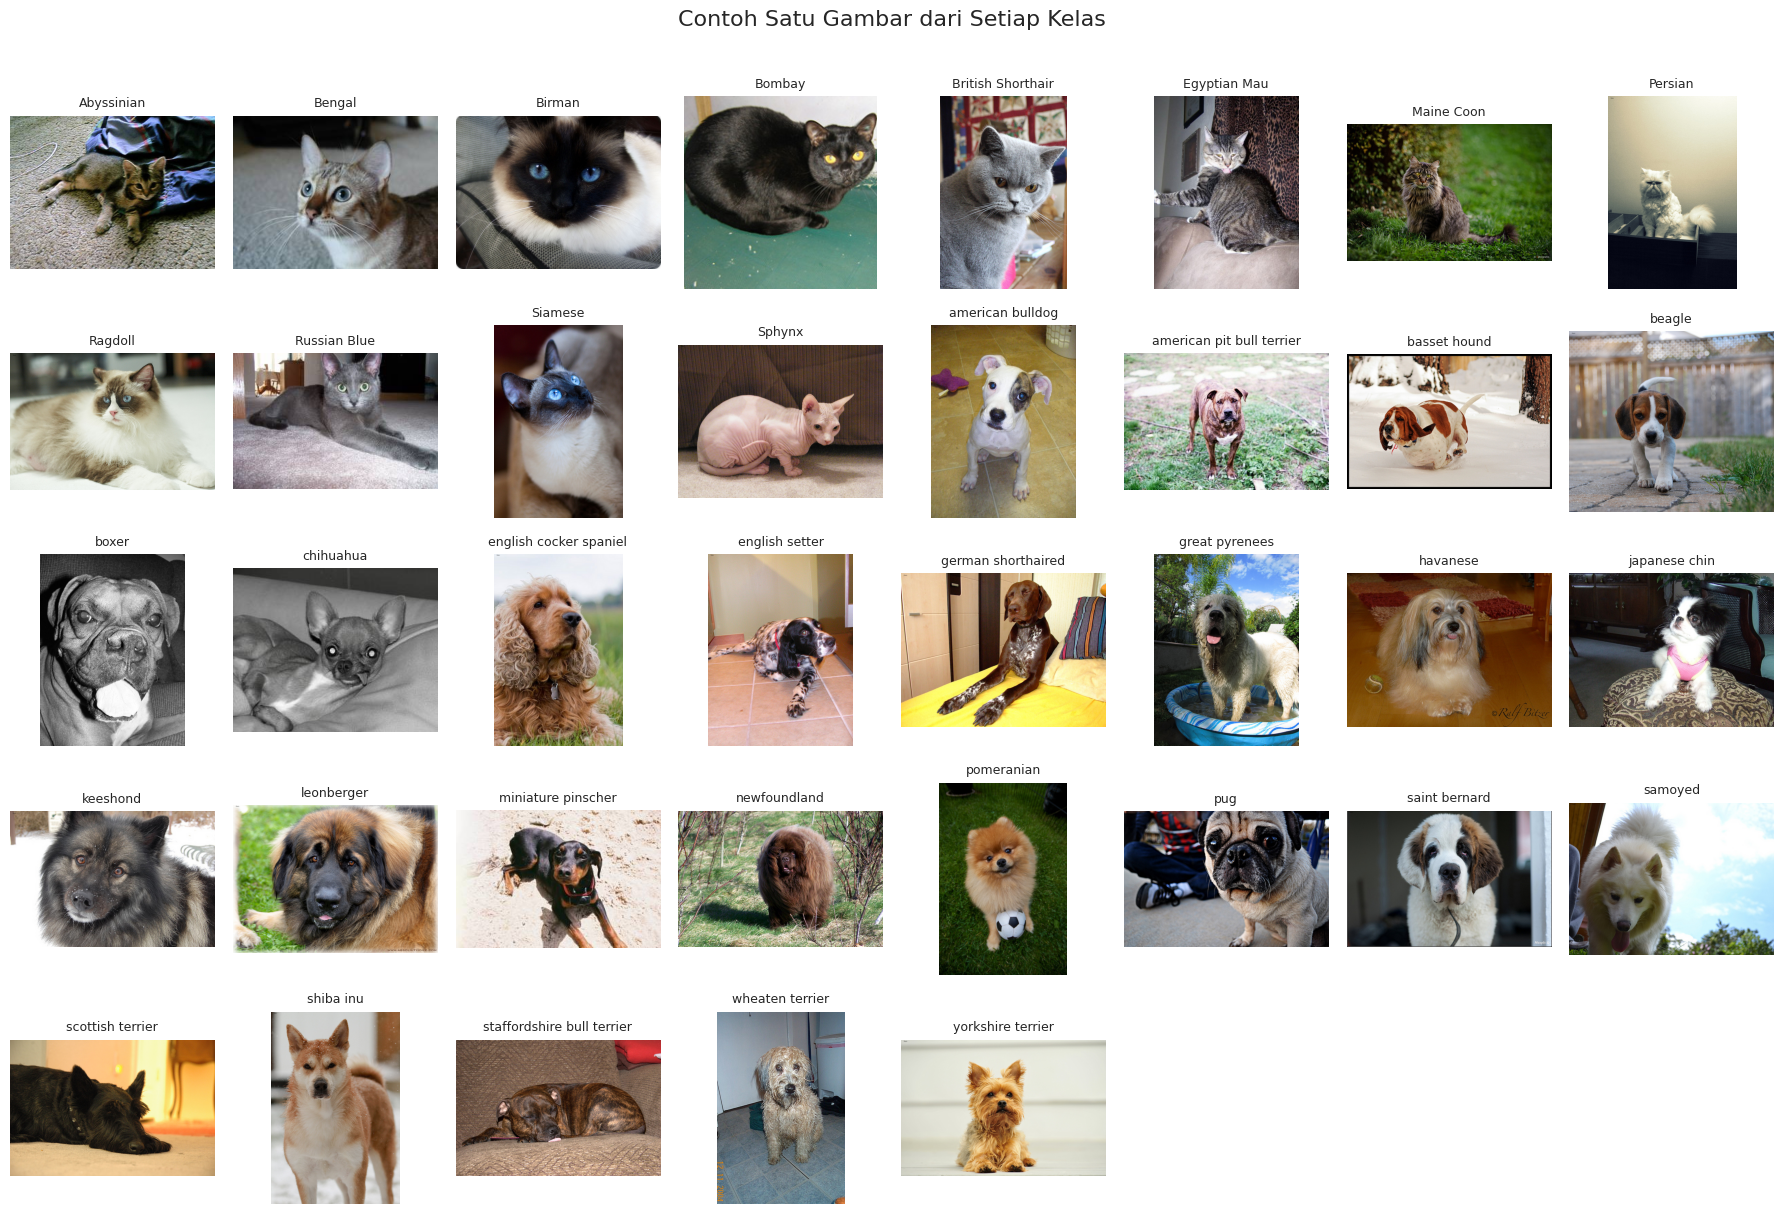

Tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures/01_sample_37_classes.png


In [27]:
sample_per_class = (
    dataset_df.groupby("class_name", group_keys=False)
    .sample(n=1, random_state=SEED)
    .sort_values("class_name")
    .reset_index(drop=True)
)

fig, axes = plt.subplots(5, 8, figsize=(18, 12))
axes = axes.flatten()

for axis, row in zip(axes, sample_per_class.itertuples(index=False)):
    with Image.open(row.image_path) as image:
        image = ImageOps.exif_transpose(image).convert("RGB")
        axis.imshow(image)
    axis.set_title(row.class_name.replace("_", " "), fontsize=9)
    axis.axis("off")

for axis in axes[len(sample_per_class) :]:
    axis.axis("off")

fig.suptitle("Contoh Satu Gambar dari Setiap Kelas", fontsize=16, y=1.01)
plt.tight_layout()

sample_grid_path = FIGURE_DIR / "01_sample_37_classes.png"
plt.savefig(sample_grid_path, dpi=300, bbox_inches="tight")
plt.show()

print("Tersimpan:", sample_grid_path)

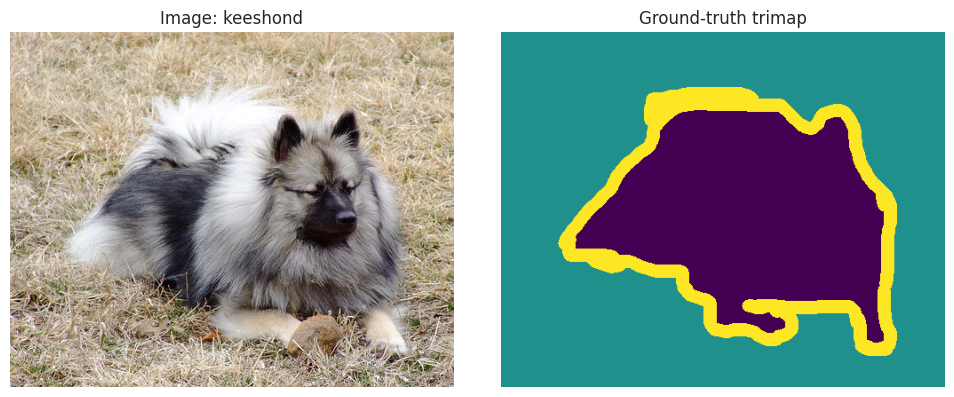

Tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures/01_trimap_example.png


In [28]:
trimap_dir = LOCAL_ANNOTATIONS_DIR / "trimaps"
example_row = dataset_df.sample(n=1, random_state=SEED).iloc[0]
example_trimap_path = trimap_dir / f"{example_row['image_name']}.png"

if example_trimap_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    with Image.open(example_row["image_path"]) as image:
        axes[0].imshow(ImageOps.exif_transpose(image).convert("RGB"))
    axes[0].set_title(f"Image: {example_row['class_name']}")
    axes[0].axis("off")

    with Image.open(example_trimap_path) as trimap:
        axes[1].imshow(trimap, cmap="viridis", vmin=1, vmax=3)
    axes[1].set_title("Ground-truth trimap")
    axes[1].axis("off")

    plt.tight_layout()
    trimap_example_path = FIGURE_DIR / "01_trimap_example.png"
    plt.savefig(trimap_example_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Tersimpan:", trimap_example_path)
else:
    print("Trimap untuk contoh terpilih tidak ditemukan; visualisasi dilewati.")

## 7. Membuat train/validation/test split

Seluruh gambar berlabel dari pembagian resmi `trainval` dan `test` digabungkan,
kemudian dibagi ulang menggunakan custom stratified split:

- 70% training
- 15% validation
- 15% testing

Stratifikasi dilakukan berdasarkan label ras agar seluruh 37 kelas memiliki
proporsi yang relatif seimbang pada setiap split. Kolom `official_split` tetap
dipertahankan untuk keperluan audit dan penelusuran terhadap pembagian resmi
Oxford-IIIT Pet.

Random seed 42 digunakan agar pembagian data dapat direproduksi.

In [21]:
# ============================================================
# Custom stratified split: 70% train, 15% validation, 15% test
# ============================================================

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15

assert np.isclose(
    TRAIN_FRACTION + VAL_FRACTION + TEST_FRACTION,
    1.0,
), "Total proporsi split harus sama dengan 1."

# Menggabungkan seluruh data berlabel.
# Kolom official_split tetap ada di dalam dataset_df.
split_source_df = dataset_df.copy()

assert split_source_df["image_name"].is_unique, (
    "Ditemukan image_name duplikat sebelum pembagian data."
)

# Tahap 1:
# 70% untuk train dan 30% untuk validation + test.
train_df, temporary_df = train_test_split(
    split_source_df,
    test_size=VAL_FRACTION + TEST_FRACTION,
    random_state=SEED,
    stratify=split_source_df["class_idx"],
)

# Tahap 2:
# Membagi temporary_df sama besar menjadi validation dan test.
relative_test_fraction = TEST_FRACTION / (
    VAL_FRACTION + TEST_FRACTION
)

val_df, test_df_final = train_test_split(
    temporary_df,
    test_size=relative_test_fraction,
    random_state=SEED,
    stratify=temporary_df["class_idx"],
)

# Memberikan label split baru.
train_df = train_df.copy()
val_df = val_df.copy()
test_df_final = test_df_final.copy()

train_df["split"] = "train"
val_df["split"] = "validation"
test_df_final["split"] = "test"

# Mengurutkan metadata agar lebih mudah diperiksa.
train_df = train_df.sort_values(
    ["class_idx", "image_name"]
).reset_index(drop=True)

val_df = val_df.sort_values(
    ["class_idx", "image_name"]
).reset_index(drop=True)

test_df_final = test_df_final.sort_values(
    ["class_idx", "image_name"]
).reset_index(drop=True)

# Menggabungkan kembali metadata final.
final_split_df = pd.concat(
    [train_df, val_df, test_df_final],
    ignore_index=True,
)

split_summary = (
    final_split_df.groupby("split")
    .agg(
        images=("image_name", "count"),
        classes=("class_idx", "nunique"),
    )
    .reindex(["train", "validation", "test"])
    .reset_index()
)

split_summary["percentage"] = (
    split_summary["images"] / len(final_split_df) * 100
).round(2)

display(split_summary)

,split,images,classes,percentage
0,train,5144,37,70.00
1,validation,1102,37,15.00
2,test,1103,37,15.01


### Pemeriksaan kebocoran data dan cakupan kelas

In [22]:
# ============================================================
# Pemeriksaan data leakage dan cakupan kelas
# ============================================================

train_names = set(train_df["image_name"])
val_names = set(val_df["image_name"])
test_names = set(test_df_final["image_name"])

assert train_names.isdisjoint(val_names), (
    "Data leakage ditemukan antara train dan validation."
)

assert train_names.isdisjoint(test_names), (
    "Data leakage ditemukan antara train dan test."
)

assert val_names.isdisjoint(test_names), (
    "Data leakage ditemukan antara validation dan test."
)

assert len(final_split_df) == len(split_source_df), (
    "Jumlah data setelah split tidak sama dengan data awal."
)

assert final_split_df["image_name"].is_unique, (
    "Terdapat gambar yang muncul lebih dari satu kali."
)

assert set(final_split_df["image_name"]) == set(
    split_source_df["image_name"]
), "Ada gambar yang hilang atau bertambah setelah split."

for split_name, current_df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df_final),
]:
    number_of_classes = current_df["class_idx"].nunique()

    assert number_of_classes == 37, (
        f"Split {split_name} hanya memiliki "
        f"{number_of_classes} kelas."
    )

print("Pemeriksaan split berhasil.")
print("Tidak ditemukan data leakage.")
print("Semua gambar digunakan tepat satu kali.")
print("Ketiga split mencakup seluruh 37 kelas.")

Pemeriksaan split berhasil.
Tidak ditemukan data leakage.
Semua gambar digunakan tepat satu kali.
Ketiga split mencakup seluruh 37 kelas.


In [23]:
# ============================================================
# Distribusi kelas pada custom split
# ============================================================

split_class_distribution = (
    final_split_df.groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["train", "validation", "test"])
)

display(split_class_distribution)

print("\nRentang jumlah gambar per kelas:")

display(
    split_class_distribution.agg(["min", "max", "mean"])
    .round(2)
)

split,train,validation,test
class_name,,,
Abyssinian,139,29,30
Bengal,140,30,30
Birman,140,30,30
Bombay,129,28,27
British_Shorthair,140,30,30
Egyptian_Mau,133,29,28
Maine_Coon,140,30,30
Persian,140,30,30
Ragdoll,140,30,30



Rentang jumlah gambar per kelas:


split,train,validation,test
min,129.00,28.00,27.00
max,140.00,30.00,30.00
mean,139.03,29.78,29.81


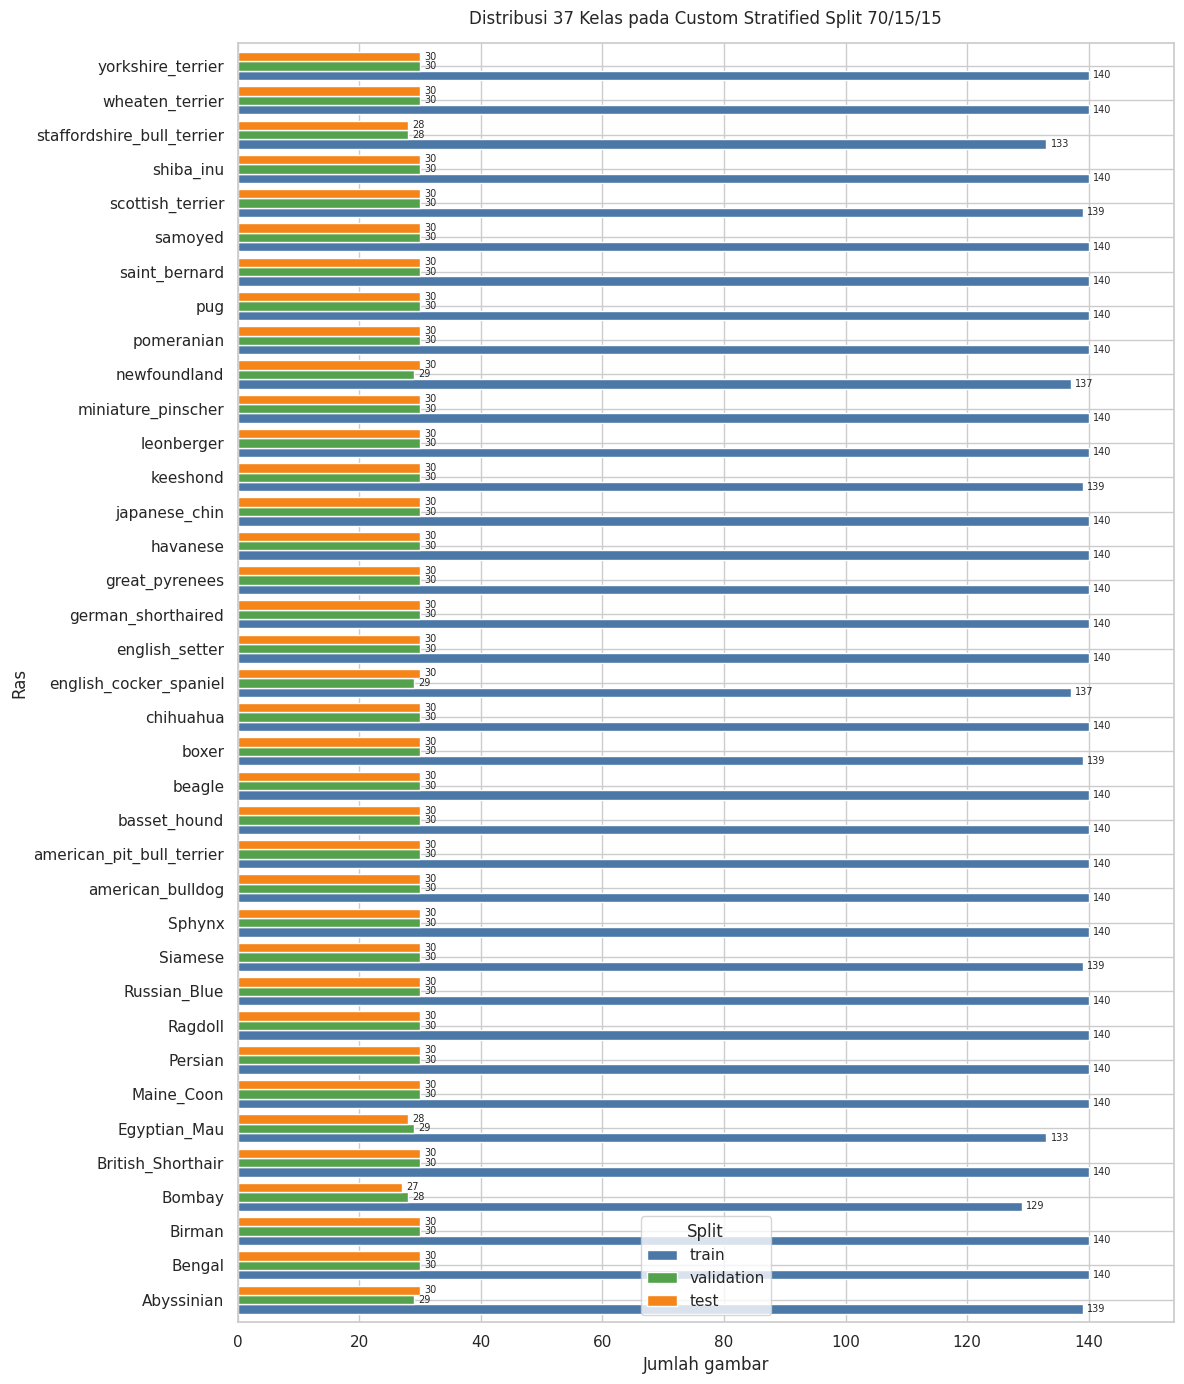

Tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures/01_custom_split_distribution_70_15_15.png


In [27]:
fig, ax = plt.subplots(figsize=(12, 14))

split_class_distribution.plot(
    kind="barh",
    width=0.82,
    color=["#4C78A8", "#54A24B", "#F58518"],
    ax=ax,
)

# Add value labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=7)

ax.set_title(
    "Distribusi 37 Kelas pada Custom Stratified Split 70/15/15",
    pad=14,
)
ax.set_xlabel("Jumlah gambar")
ax.set_ylabel("Ras")
ax.legend(title="Split")

# Adjust x-axis margin so end labels aren't clipped
ax.margins(x=0.1)

plt.tight_layout()

final_split_figure_path = (
    FIGURE_DIR / "01_custom_split_distribution_70_15_15.png"
)

plt.savefig(
    final_split_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Tersimpan:", final_split_figure_path)

## 8. Menyimpan metadata untuk notebook 02 dan 03

CSV tidak menyimpan absolute path `/content/...` agar tetap portabel di sesi
Colab berikutnya. Notebook training cukup menggabungkan `LOCAL_IMAGES_DIR` dengan
kolom `file_name`.

In [25]:
# ============================================================
# Menentukan kolom metadata yang akan disimpan
# ============================================================

base_save_columns = [
    "image_name",
    "file_name",
    "class_id",
    "class_idx",
    "class_name",
    "species_id",
    "species",
    "breed_id",
    "official_split",
]

optional_image_columns = [
    "width",
    "height",
    "aspect_ratio",
    "file_size_kb",
    "image_mode",
]

save_columns = base_save_columns.copy()

save_columns.extend(
    column
    for column in optional_image_columns
    if column in final_split_df.columns
)

save_columns.append("split")

print("Kolom yang akan disimpan:")
print(save_columns)

Kolom yang akan disimpan:
['image_name', 'file_name', 'class_id', 'class_idx', 'class_name', 'species_id', 'species', 'breed_id', 'official_split', 'width', 'height', 'aspect_ratio', 'file_size_kb', 'image_mode', 'split']


In [26]:
# ============================================================
# Lokasi file metadata
# ============================================================

train_csv_path = METADATA_DIR / "train_split.csv"
val_csv_path = METADATA_DIR / "val_split.csv"
test_csv_path = METADATA_DIR / "test_split.csv"
all_metadata_path = METADATA_DIR / "all_labeled_images.csv"

class_map_path = METADATA_DIR / "class_map.json"
summary_json_path = METADATA_DIR / "dataset_summary.json"
config_json_path = METADATA_DIR / "eda_config.json"
quality_csv_path = METADATA_DIR / "image_quality_summary.csv"

# Menyimpan metadata masing-masing split.
train_df[save_columns].to_csv(
    train_csv_path,
    index=False,
)

val_df[save_columns].to_csv(
    val_csv_path,
    index=False,
)

test_df_final[save_columns].to_csv(
    test_csv_path,
    index=False,
)

final_split_df[save_columns].to_csv(
    all_metadata_path,
    index=False,
)

print("CSV split berhasil disimpan.")

CSV split berhasil disimpan.


In [28]:
# ============================================================
# Mapping indeks model 0–36 ke nama ras
# ============================================================

class_rows = (
    dataset_df.sort_values("class_idx")
    .drop_duplicates("class_idx")
    [
        [
            "class_idx",
            "class_id",
            "class_name",
            "species",
        ]
    ]
)

class_map = {
    str(int(row.class_idx)): {
        "class_id": int(row.class_id),
        "class_name": row.class_name,
        "display_name": row.class_name.replace("_", " "),
        "species": row.species,
    }
    for row in class_rows.itertuples(index=False)
}

with class_map_path.open(
    "w",
    encoding="utf-8",
) as file_obj:
    json.dump(
        class_map,
        file_obj,
        indent=2,
        ensure_ascii=False,
    )

print("Class map tersimpan:", class_map_path)

Class map tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/metadata/class_map.json


In [29]:
# ============================================================
# Ringkasan dataset
# ============================================================

dataset_summary = {
    "dataset_name": "Oxford-IIIT Pet Dataset",
    "task": "37-class pet breed image classification",
    "number_of_classes": int(
        dataset_df["class_idx"].nunique()
    ),
    "number_of_labeled_images": int(
        len(dataset_df)
    ),
    "split_strategy": (
        "Custom stratified 70/15/15 split from pooled "
        "official trainval and test data"
    ),
    "split_counts": {
        "train": int(len(train_df)),
        "validation": int(len(val_df)),
        "test": int(len(test_df_final)),
    },
    "split_percentages": {
        "train": round(
            len(train_df) / len(dataset_df) * 100,
            4,
        ),
        "validation": round(
            len(val_df) / len(dataset_df) * 100,
            4,
        ),
        "test": round(
            len(test_df_final) / len(dataset_df) * 100,
            4,
        ),
    },
    "species_counts": {
        key: int(value)
        for key, value
        in dataset_df["species"].value_counts().items()
    },
}

with summary_json_path.open(
    "w",
    encoding="utf-8",
) as file_obj:
    json.dump(
        dataset_summary,
        file_obj,
        indent=2,
        ensure_ascii=False,
    )

print("Dataset summary tersimpan:", summary_json_path)

Dataset summary tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/metadata/dataset_summary.json


In [30]:
# ============================================================
# Konfigurasi split untuk notebook 02 dan 03
# ============================================================

eda_config = {
    "random_seed": SEED,
    "train_fraction": TRAIN_FRACTION,
    "validation_fraction": VAL_FRACTION,
    "test_fraction": TEST_FRACTION,
    "split_strategy": (
        "pooled official trainval and test, followed by "
        "stratified random split"
    ),
    "stratification_column": "class_idx",
    "target_column": "class_idx",
    "number_of_classes": 37,
    "persistent_dataset_root": str(DRIVE_DATASET_DIR),
    "runtime_dataset_root": str(LOCAL_ROOT),
    "metadata_directory": str(METADATA_DIR),
}

with config_json_path.open(
    "w",
    encoding="utf-8",
) as file_obj:
    json.dump(
        eda_config,
        file_obj,
        indent=2,
        ensure_ascii=False,
    )

if not image_metadata_df.empty:
    image_metadata_df.to_csv(
        quality_csv_path,
        index=False,
    )

print("Konfigurasi tersimpan:", config_json_path)

Konfigurasi tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/metadata/eda_config.json


## 9. Verifikasi output akhir

In [31]:
# ============================================================
# Verifikasi file output
# ============================================================

expected_metadata_files = [
    train_csv_path,
    val_csv_path,
    test_csv_path,
    all_metadata_path,
    class_map_path,
    summary_json_path,
    config_json_path,
]

metadata_check = pd.DataFrame(
    [
        {
            "file": path.name,
            "folder": str(path.parent),
            "exists": path.exists(),
            "size_kb": (
                round(path.stat().st_size / 1024, 2)
                if path.exists()
                else np.nan
            ),
        }
        for path in expected_metadata_files
    ]
)

display(metadata_check)

assert metadata_check["exists"].all(), (
    "Ada file metadata yang gagal disimpan."
)

# Membaca kembali CSV untuk memastikan hasil tersimpan dengan benar.
saved_train_df = pd.read_csv(train_csv_path)
saved_val_df = pd.read_csv(val_csv_path)
saved_test_df = pd.read_csv(test_csv_path)

assert len(saved_train_df) == len(train_df)
assert len(saved_val_df) == len(val_df)
assert len(saved_test_df) == len(test_df_final)

assert set(saved_train_df["class_idx"]) == set(range(37))
assert set(saved_val_df["class_idx"]) == set(range(37))
assert set(saved_test_df["class_idx"]) == set(range(37))

print("=" * 70)
print("NOTEBOOK 01 SELESAI")
print("=" * 70)
print(f"Train images      : {len(saved_train_df):,}")
print(f"Validation images : {len(saved_val_df):,}")
print(f"Test images       : {len(saved_test_df):,}")
print(f"Number of classes : {saved_train_df['class_idx'].nunique()}")
print(f"Dataset folder    : {DRIVE_DATASET_DIR}")
print(f"Metadata folder   : {METADATA_DIR}")
print(f"Figure folder     : {FIGURE_DIR}")

,file,folder,exists,size_kb
0,train_split.csv,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/met...,True,583.93
1,val_split.csv,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/met...,True,130.09
2,test_split.csv,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/met...,True,124.21
3,all_labeled_images.csv,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/met...,True,837.94
4,class_map.json,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/met...,True,4.51
5,dataset_summary.json,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/met...,True,0.50
6,eda_config.json,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/met...,True,0.61


NOTEBOOK 01 SELESAI
Train images      : 5,144
Validation images : 1,102
Test images       : 1,103
Number of classes : 37
Dataset folder    : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/oxford_iiit_pet
Metadata folder   : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/metadata
Figure folder     : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures
